# 📊 Notebook 01: Análisis Exploratorio de Datos (EDA)

**Proyecto:** Sistema de Detección de Phishing con Machine Learning  
**Autor:** [Tu Nombre]  
**Universidad:** [Tu Universidad]  
**Fecha:** 2024-2025

---

## Objetivos

1. ✅ Cargar dataset UCI PhiUSIIL + datos externos
2. ✅ Análisis de distribución de clases
3. ✅ Detección de valores nulos y outliers
4. ✅ Análisis de correlación entre features
5. ✅ Visualizaciones profesionales
6. ✅ Estadísticas descriptivas completas

---

## 1. Importar Librerías

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Módulos propios
from data_loader import DataLoader
from feature_engineering import CorrelationAnalyzer

# Configuración
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

%matplotlib inline

print("✓ Librerías importadas exitosamente")

✓ Librerías importadas exitosamente


## 2. Cargar Dataset

Cargamos el dataset UCI PhiUSIIL y opcionalmente los datos externos.

In [2]:
# Inicializar cargador de datos
loader = DataLoader(data_dir='../data')

# Cargar todos los datos (UCI + externos si existen)
print("Cargando datasets...")
X, y, info = loader.load_all_data(
    include_external=True,  # Incluir datos de PhishTank y Perú
    force_download_uci=False
)

# IMPORTANTE: Seleccionar solo columnas numéricas
X = X.select_dtypes(include=[np.number])

print("\n[OK] Datos cargados exitosamente")
print(f"\nShape: {X.shape}")
print(f"  - Muestras: {len(X):,}")
print(f"  - Features numericas: {X.shape[1]}")

2025-11-19 17:52:44,793 - data_loader - INFO - UCIDatasetLoader inicializado. Directorio: ../data


2025-11-19 17:52:44,794 - data_loader - INFO - ExternalDataLoader inicializado. Directorio: ../data\external


2025-11-19 17:52:44,794 - data_loader - INFO - DatasetCombiner inicializado


2025-11-19 17:52:44,794 - data_loader - INFO - DataLoader principal inicializado


2025-11-19 17:52:44,794 - data_loader - INFO - === Iniciando carga completa de datos ===


...

2025-11-19 17:53:09,775 - data_loader - INFO - No hay datos externos. Usando solo dataset UCI


2025-11-19 17:53:09,775 - data_loader - INFO - === Carga de datos completada ===


2025-11-19 17:53:09,775 - data_loader - INFO - Total final de samples: 235795


2025-11-19 17:53:09,775 - data_loader - INFO - Balance de clases: {1: 57.189507835195826, 0: 42.810492164804174}



[OK] Datos cargados exitosamente

Shape: (235795, 50)
  - Muestras: 235,795
  - Features numericas: 50


### 2.1 Información del Dataset

In [3]:
print("=" * 70)
print("                   INFORMACIÓN DEL DATASET")
print("=" * 70)

print(f"\nDataset UCI:")
print(f"  - Samples: {info['uci_info']['n_samples']:,}")
print(f"  - Features: {info['uci_info']['n_features']}")
print(f"  - Phishing: {info['uci_info']['n_phishing']:,}")
print(f"  - Legitimate: {info['uci_info']['n_legitimate']:,}")

if info['external_included']:
    print(f"\nDatos Externos:")
    print(f"  - Samples adicionales: {info['external_samples']:,}")

print(f"\nDataset Final:")
print(f"  - Total samples: {info['final_shape'][0]:,}")
print(f"  - Total features: {info['final_shape'][1]}")
print(f"\nBalance de clases:")
for label, pct in info['balance_info']['class_percentages'].items():
    print(f"  - Clase {label}: {pct:.2f}%")

print("\n" + "=" * 70)

                   INFORMACIÓN DEL DATASET

Dataset UCI:
  - Samples: 235,795
  - Features: 54
  - Phishing: 134,850
  - Legitimate: 100,945

Dataset Final:
  - Total samples: 235,795
  - Total features: 54

Balance de clases:
  - Clase 1: 57.19%
  - Clase 0: 42.81%



## 3. Análisis de Distribución de Clases

Distribución de Clases:
0    100945
1    134850
Name: count, dtype: int64

Proporción:
0    0.428105
1    0.571895
Name: count, dtype: float64


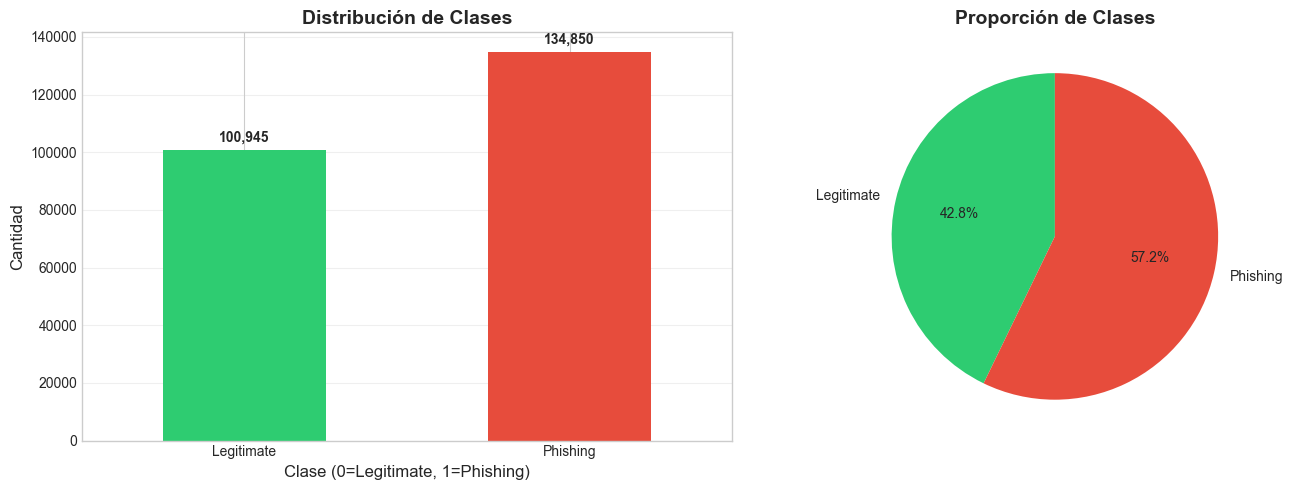


Balance ratio: 0.749
⚠ Dataset desbalanceado - Se requerirá balanceo


In [4]:
# Contar clases
class_counts = y.value_counts().sort_index()

print("Distribución de Clases:")
print(class_counts)
print(f"\nProporción:")
print(class_counts / len(y))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
ax1 = axes[0]
class_counts.plot(kind='bar', ax=ax1, color=['#2ecc71', '#e74c3c'])
ax1.set_title('Distribución de Clases', fontsize=14, fontweight='bold')
ax1.set_xlabel('Clase (0=Legitimate, 1=Phishing)', fontsize=12)
ax1.set_ylabel('Cantidad', fontsize=12)
ax1.set_xticklabels(['Legitimate', 'Phishing'], rotation=0)
ax1.grid(axis='y', alpha=0.3)

# Agregar valores
for i, v in enumerate(class_counts):
    ax1.text(i, v + max(class_counts)*0.02, f'{v:,}', ha='center', fontweight='bold')

# Gráfico de torta
ax2 = axes[1]
class_counts.plot(
    kind='pie',
    ax=ax2,
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    labels=['Legitimate', 'Phishing'],
    startangle=90
)
ax2.set_title('Proporción de Clases', fontsize=14, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

# Verificar si está balanceado
balance_ratio = class_counts.min() / class_counts.max()
print(f"\nBalance ratio: {balance_ratio:.3f}")
if balance_ratio > 0.8:
    print("✓ Dataset balanceado")
else:
    print("⚠ Dataset desbalanceado - Se requerirá balanceo")

## 4. Análisis de Valores Nulos

In [5]:
# Verificar valores nulos
null_counts = X.isnull().sum()
null_percentage = (X.isnull().sum() / len(X)) * 100

print("=" * 70)
print("ANÁLISIS DE VALORES NULOS")
print("=" * 70)
print(f"\nTotal de valores nulos: {X.isnull().sum().sum()}")

if X.isnull().sum().sum() > 0:
    print("\nColumnas con valores nulos:")
    null_cols = null_counts[null_counts > 0]
    for col, count in null_cols.items():
        pct = null_percentage[col]
        print(f"  - {col}: {count} ({pct:.2f}%)")
    
    # Visualización
    if len(null_cols) > 0:
        plt.figure(figsize=(12, 6))
        null_cols.plot(kind='bar', color='#e74c3c')
        plt.title('Valores Nulos por Columna', fontsize=14, fontweight='bold')
        plt.xlabel('Columnas', fontsize=12)
        plt.ylabel('Cantidad de Nulos', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
else:
    print("\n✓ No hay valores nulos en el dataset")

ANÁLISIS DE VALORES NULOS

Total de valores nulos: 0

✓ No hay valores nulos en el dataset


## 5. Estadísticas Descriptivas

In [6]:
# Estadísticas descriptivas
print("=" * 70)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 70)
print(X.describe())

# Guardar en CSV para referencia
stats_path = '../results/metrics/descriptive_statistics.csv'
X.describe().to_csv(stats_path)
print(f"\n✓ Estadísticas guardadas en: {stats_path}")

ESTADÍSTICAS DESCRIPTIVAS


           URLLength   DomainLength     IsDomainIP  URLSimilarityIndex  \
count  235795.000000  235795.000000  235795.000000       235795.000000   
mean       34.573095      21.470396       0.002706           78.430778   
std        41.314153       9.150793       0.051946           28.976055   
min        13.000000       4.000000       0.000000            0.155574   
25%        23.000000      16.000000       0.000000           57.024793   
50%        27.000000      20.000000       0.000000          100.000000   
75%        34.000000      24.000000       0.000000          100.000000   
max      6097.000000     110.000000       1.000000          100.000000   

       CharContinuationRate  TLDLegitimateProb    URLCharProb      TLDLength  \
count         235795.000000      235795.000000  235795.000000  235795.000000   
mean               0.845508           0.260423       0.055747       2.764456   
std                0.216632           0.251628       0.010587       0.599739   
min          


✓ Estadísticas guardadas en: ../results/metrics/descriptive_statistics.csv


### 5.1 Distribución de Features Principales

In [7]:
# Seleccionar features clave para visualizar
key_features = [
    'url_length',
    'domain_length',
    'count_dots',
    'count_hyphens',
    'is_https',
    'has_ip_address',
    'count_suspicious_words',
    'url_entropy'
]

# Verificar que las features existan
key_features = [f for f in key_features if f in X.columns]

# Crear histogramas
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, feature in enumerate(key_features[:9]):
    ax = axes[idx]
    
    # Histograma por clase
    X[y == 0][feature].hist(ax=ax, bins=30, alpha=0.6, label='Legitimate', color='green')
    X[y == 1][feature].hist(ax=ax, bins=30, alpha=0.6, label='Phishing', color='red')
    
    ax.set_title(feature, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend()
    ax.grid(alpha=0.3)

# Ocultar ejes no usados
for idx in range(len(key_features), 9):
    fig.delaxes(axes[idx])

plt.suptitle('Distribución de Features Principales', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

<Figure size 1500x1200 with 0 Axes>

## 6. Análisis de Outliers

ANÁLISIS DE OUTLIERS (Método IQR)

Total de outliers detectados: 719,733

Top 10 features con más outliers:
  NoOfSubDomain: 57,389 (24.34%)
  Pay: 55,885 (23.70%)
  NoOfDegitsInURL: 51,461 (21.82%)
  DegitRatioInURL: 51,461 (21.82%)
  IsHTTPS: 51,256 (21.74%)
  NoOfEmptyRef: 38,885 (16.49%)
  NoOfiFrame: 34,441 (14.61%)
  HasTitle: 32,714 (13.87%)
  NoOfURLRedirect: 31,464 (13.34%)
  Bank: 29,967 (12.71%)


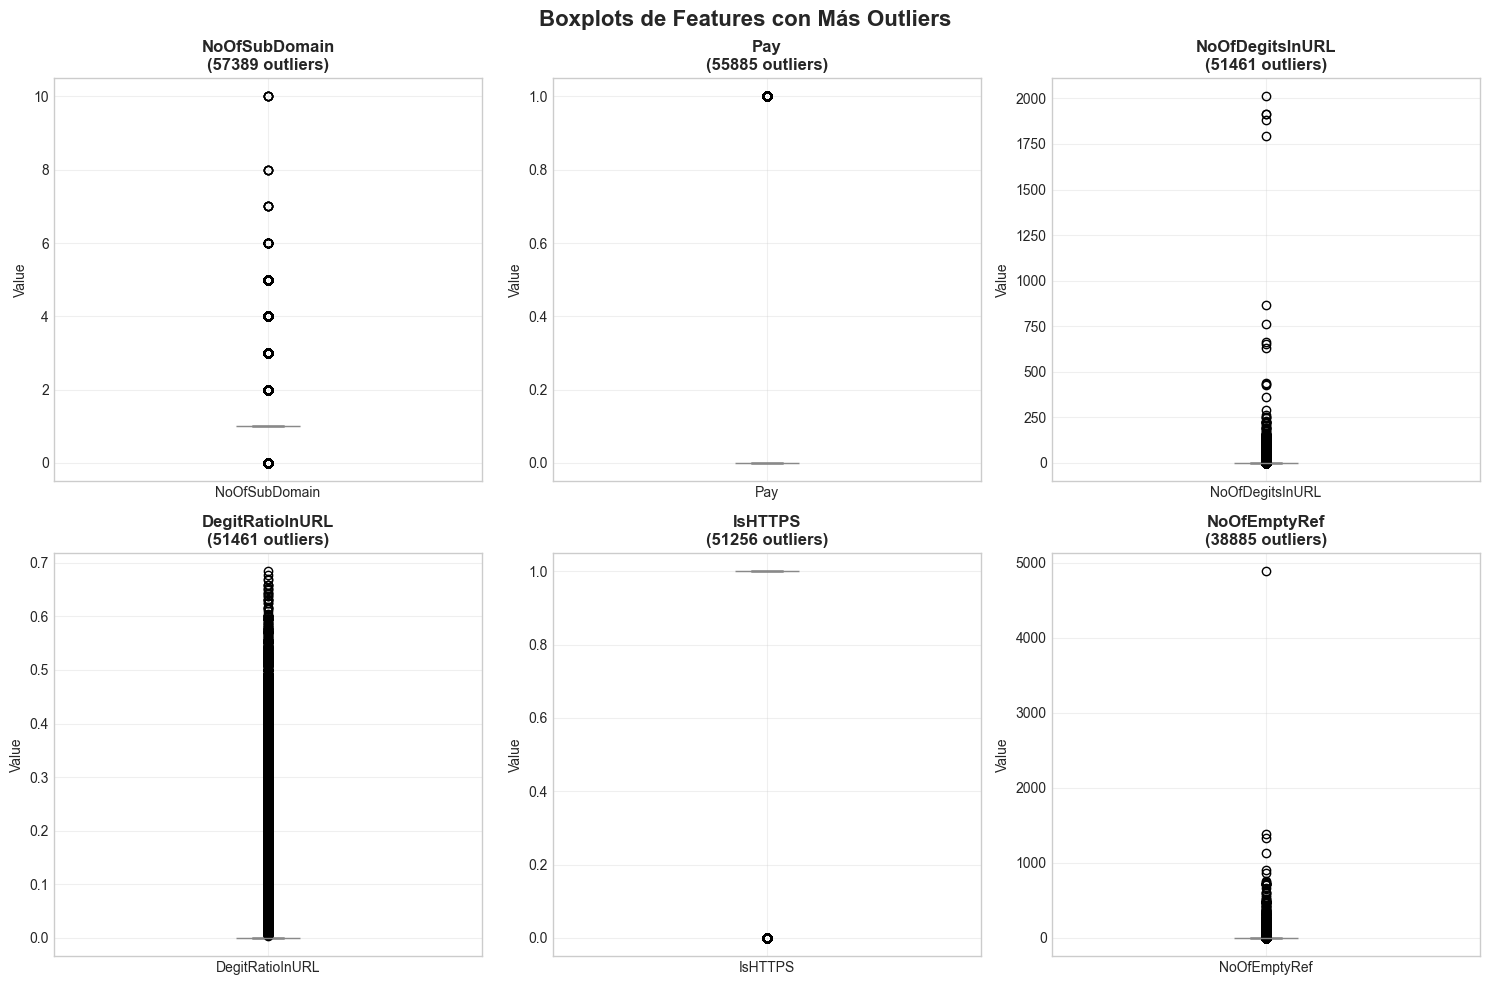

In [8]:
# Detección de outliers usando IQR
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

# Contar outliers por feature
outliers = ((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).sum()
outlier_percentage = (outliers / len(X)) * 100

print("=" * 70)
print("ANÁLISIS DE OUTLIERS (Método IQR)")
print("=" * 70)
print(f"\nTotal de outliers detectados: {outliers.sum():,}")

# Top features con más outliers
top_outliers = outliers.sort_values(ascending=False).head(10)
print("\nTop 10 features con más outliers:")
for feature, count in top_outliers.items():
    pct = outlier_percentage[feature]
    print(f"  {feature}: {count:,} ({pct:.2f}%)")

# Visualización de boxplots
features_to_plot = top_outliers.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx]
    X.boxplot(column=feature, ax=ax)
    ax.set_title(f'{feature}\n({top_outliers[feature]} outliers)', fontweight='bold')
    ax.set_ylabel('Value')
    ax.grid(alpha=0.3)

plt.suptitle('Boxplots de Features con Más Outliers', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Análisis de Correlación

Analizar correlaciones entre features para identificar redundancias.

In [9]:
# Calcular matriz de correlación
correlation_matrix = X.corr()

print("=" * 70)
print("ANÁLISIS DE CORRELACIÓN")
print("=" * 70)
print(f"\nMatriz de correlación calculada: {correlation_matrix.shape}")

# Encontrar pares altamente correlacionados
analyzer = CorrelationAnalyzer()
high_corr_pairs = analyzer.find_highly_correlated_pairs(X, threshold=0.9)

print(f"\nPares de features altamente correlacionadas (>0.9): {len(high_corr_pairs)}")
if len(high_corr_pairs) > 0:
    print("\nTop 10 pares más correlacionados:")
    for i, (feat1, feat2, corr) in enumerate(high_corr_pairs[:10], 1):
        print(f"  {i}. {feat1} <-> {feat2}: {corr:.4f}")

2025-11-19 17:53:13,889 - feature_engineering - INFO - CorrelationAnalyzer inicializado


2025-11-19 17:53:13,889 - feature_engineering - INFO - Buscando pares con correlación > 0.9...


ANÁLISIS DE CORRELACIÓN

Matriz de correlación calculada: (50, 50)


2025-11-19 17:53:15,136 - feature_engineering - INFO - Pares altamente correlacionados encontrados: 2



Pares de features altamente correlacionadas (>0.9): 2

Top 10 pares más correlacionados:
  1. URLLength <-> NoOfLettersInURL: 0.9560
  2. DomainTitleMatchScore <-> URLTitleMatchScore: 0.9610


### 7.1 Heatmap de Correlación (Top 30 Features)


✓ Heatmap guardado en: ../results/visualizations/correlation_heatmap_eda.png


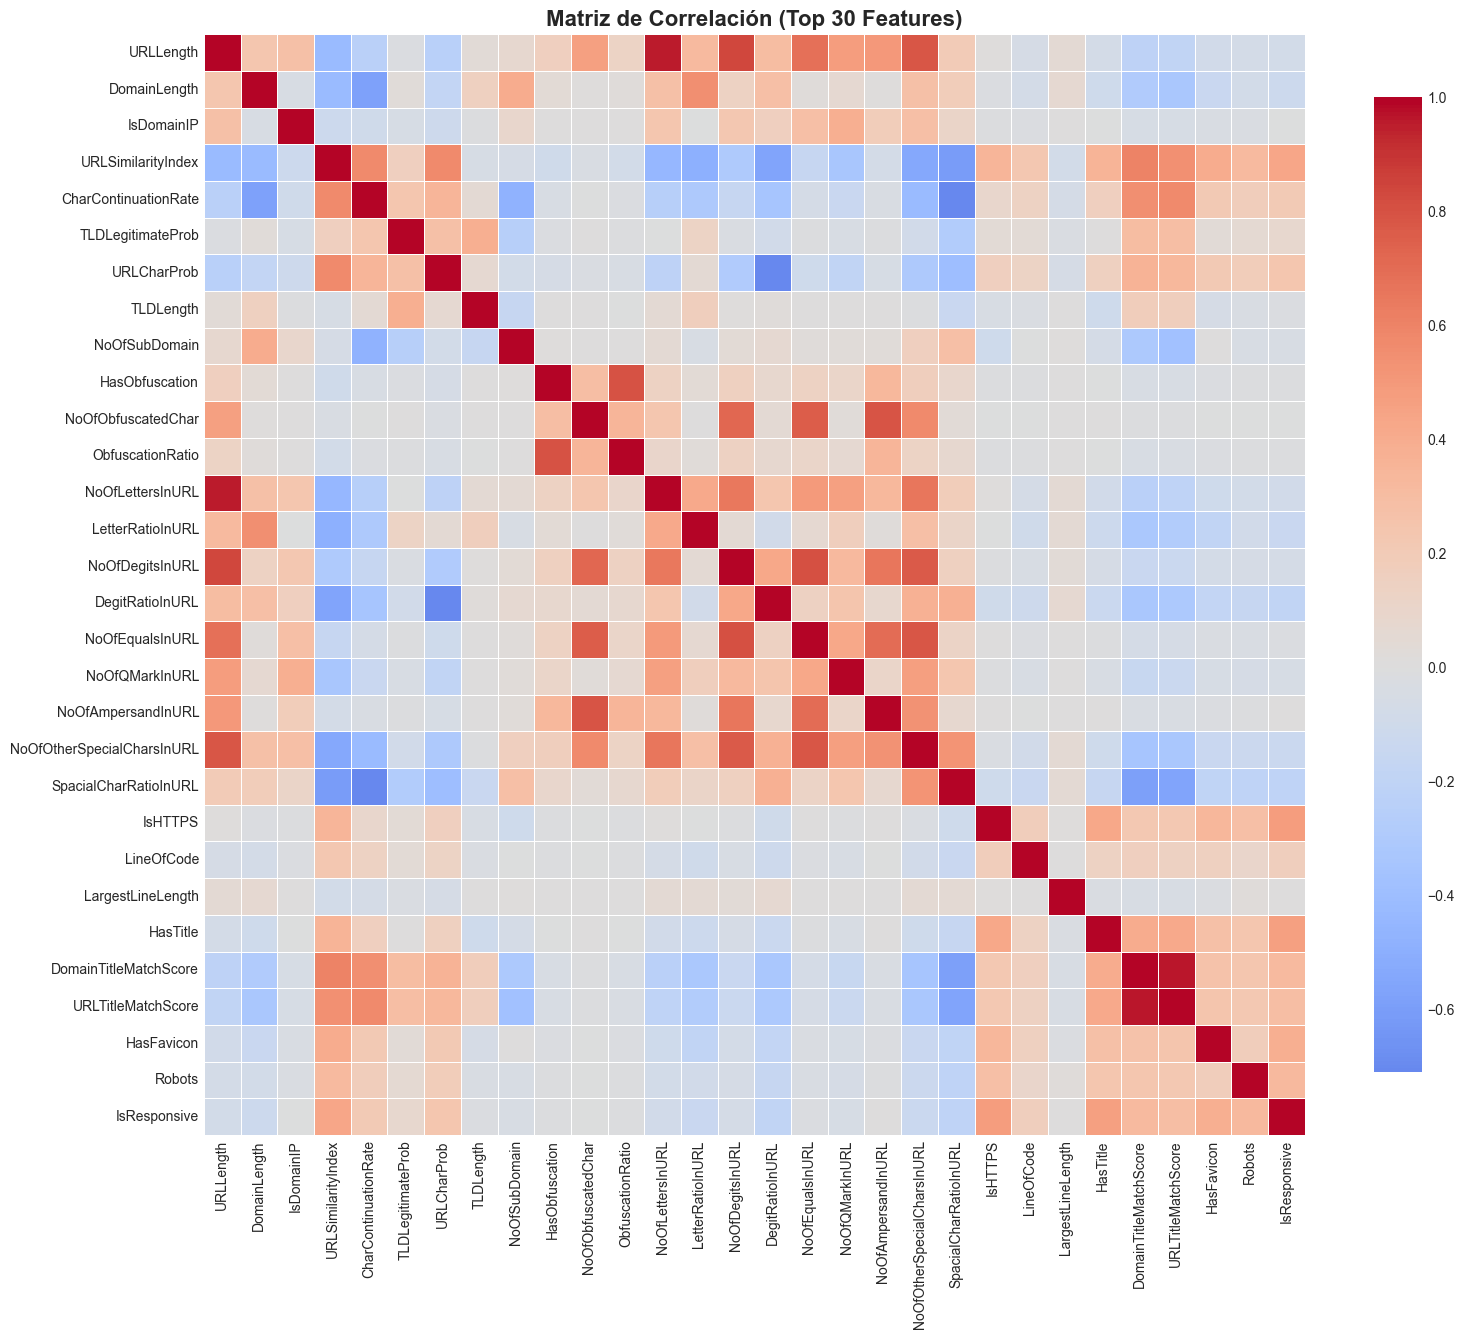

In [10]:
# Heatmap de las primeras 30 features (para mejor visualización)
top_features = X.columns[:30]
corr_subset = X[top_features].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(
    corr_subset,
    annot=False,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title('Matriz de Correlación (Top 30 Features)', fontsize=16, fontweight='bold')
plt.tight_layout()

# Guardar
output_path = '../results/visualizations/correlation_heatmap_eda.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Heatmap guardado en: {output_path}")
plt.show()

## 8. Correlación con la Variable Target

CORRELACIÓN CON LA VARIABLE TARGET

Top 20 features más correlacionadas con el target (phishing):
URLSimilarityIndex       0.860358
HasSocialNet             0.784255
HasCopyrightInfo         0.743358
HasDescription           0.690232
IsHTTPS                  0.609132
DomainTitleMatchScore    0.584905
HasSubmitButton          0.578561
IsResponsive             0.548608
URLTitleMatchScore       0.539419
SpacialCharRatioInURL    0.533537
HasHiddenFields          0.507731
HasFavicon               0.493711
URLCharProb              0.469749
CharContinuationRate     0.467735
HasTitle                 0.459725
DegitRatioInURL          0.432032
Robots                   0.392620
NoOfJS                   0.373500
LetterRatioInURL         0.367794
Pay                      0.359747
dtype: float64



✓ Gráfico guardado en: ../results/visualizations/target_correlation.png


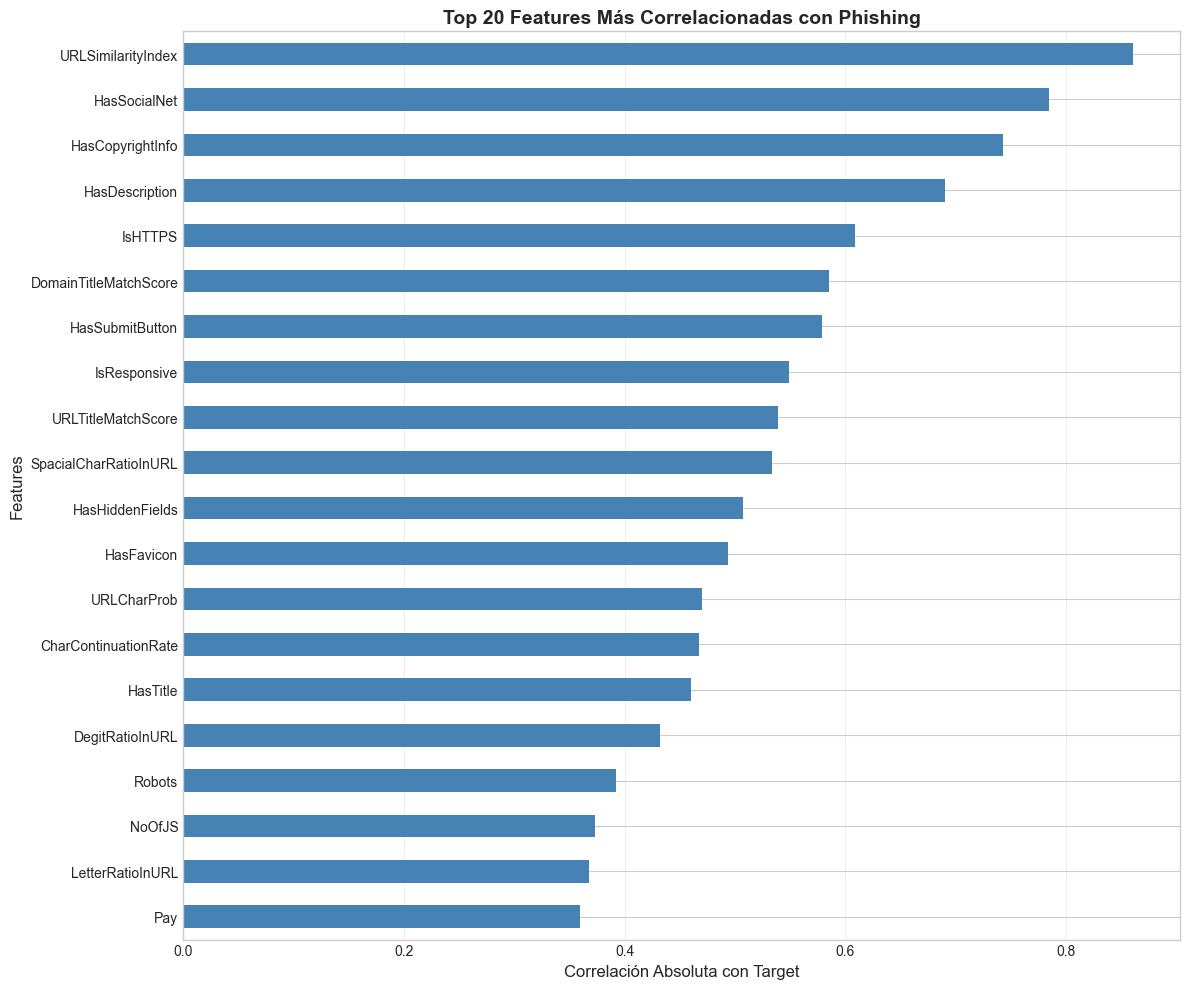

In [11]:
# Correlación de cada feature con el target
target_correlation = X.corrwith(y).abs().sort_values(ascending=False)

print("=" * 70)
print("CORRELACIÓN CON LA VARIABLE TARGET")
print("=" * 70)
print("\nTop 20 features más correlacionadas con el target (phishing):")
print(target_correlation.head(20))

# Visualización
plt.figure(figsize=(12, 10))
target_correlation.head(20).plot(kind='barh', color='steelblue')
plt.xlabel('Correlación Absoluta con Target', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Top 20 Features Más Correlacionadas con Phishing', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

# Guardar
output_path = '../results/visualizations/target_correlation.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\n✓ Gráfico guardado en: {output_path}")
plt.show()

## 9. Análisis de Varianza

ANÁLISIS DE VARIANZA

Features con baja varianza (<0.01): 6

Features con baja varianza:
DegitRatioInURL          0.005026
IsDomainIP               0.002698
HasObfuscation           0.002053
SpacialCharRatioInURL    0.001049
URLCharProb              0.000112
ObfuscationRatio         0.000015
dtype: float64


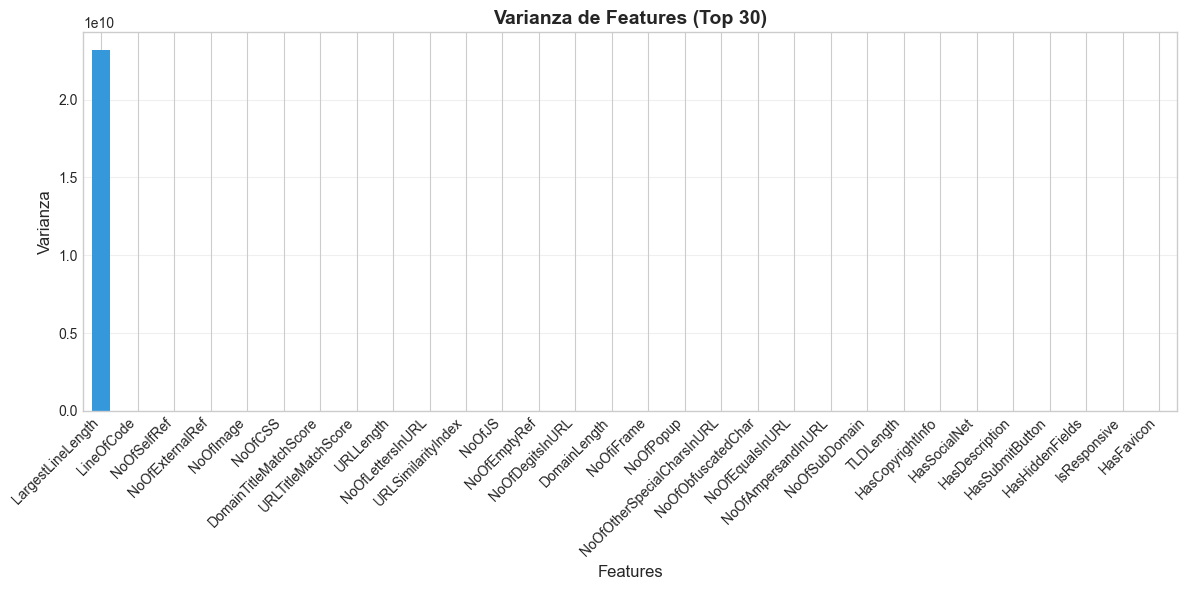

In [12]:
# Calcular varianza de cada feature
variances = X.var().sort_values(ascending=False)

print("=" * 70)
print("ANÁLISIS DE VARIANZA")
print("=" * 70)

# Features con baja varianza (posibles candidatas a eliminar)
low_variance = variances[variances < 0.01]

print(f"\nFeatures con baja varianza (<0.01): {len(low_variance)}")
if len(low_variance) > 0:
    print("\nFeatures con baja varianza:")
    print(low_variance)
else:
    print("✓ Todas las features tienen varianza adecuada")

# Visualización
plt.figure(figsize=(12, 6))
variances.head(30).plot(kind='bar', color='#3498db')
plt.title('Varianza de Features (Top 30)', fontsize=14, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Varianza', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Resumen del EDA

In [13]:
print("="*70)
print("                    RESUMEN DEL ANÁLISIS EXPLORATORIO")
print("="*70)

print(f"\n📊 DATASET:")
print(f"  - Total de muestras: {len(X):,}")
print(f"  - Total de features: {X.shape[1]}")
print(f"  - Phishing: {(y == 1).sum():,} ({(y == 1).sum()/len(y)*100:.2f}%)")
print(f"  - Legítimas: {(y == 0).sum():,} ({(y == 0).sum()/len(y)*100:.2f}%)")

print(f"\n🔍 CALIDAD DE DATOS:")
print(f"  - Valores nulos: {X.isnull().sum().sum()}")
print(f"  - Duplicados: {X.duplicated().sum()}")
print(f"  - Outliers detectados: {outliers.sum():,}")

print(f"\n📈 CORRELACIÓN:")
print(f"  - Pares altamente correlacionados (>0.9): {len(high_corr_pairs)}")
print(f"  - Feature más correlacionada con target: {target_correlation.index[0]}")
print(f"    Correlación: {target_correlation.iloc[0]:.4f}")

print(f"\n⚠️  CONSIDERACIONES:")
if balance_ratio < 0.8:
    print(f"  - Dataset desbalanceado (ratio: {balance_ratio:.3f}) - Aplicar balanceo")
else:
    print(f"  - Dataset balanceado (ratio: {balance_ratio:.3f})")

if len(low_variance) > 0:
    print(f"  - {len(low_variance)} features con baja varianza - Considerar eliminación")

if len(high_corr_pairs) > 10:
    print(f"  - Múltiples features correlacionadas - Aplicar feature selection")

print("\n" + "="*70)
print("\n✅ ANÁLISIS EXPLORATORIO COMPLETADO")
print("\n📌 Próximo paso: Notebook 02 - Preprocesamiento")
print("="*70)

                    RESUMEN DEL ANÁLISIS EXPLORATORIO

📊 DATASET:
  - Total de muestras: 235,795
  - Total de features: 50
  - Phishing: 134,850 (57.19%)
  - Legítimas: 100,945 (42.81%)

🔍 CALIDAD DE DATOS:
  - Valores nulos: 0


  - Duplicados: 808
  - Outliers detectados: 719,733

📈 CORRELACIÓN:
  - Pares altamente correlacionados (>0.9): 2
  - Feature más correlacionada con target: URLSimilarityIndex
    Correlación: 0.8604

⚠️  CONSIDERACIONES:
  - Dataset desbalanceado (ratio: 0.749) - Aplicar balanceo
  - 6 features con baja varianza - Considerar eliminación


✅ ANÁLISIS EXPLORATORIO COMPLETADO

📌 Próximo paso: Notebook 02 - Preprocesamiento
